In [ ]:
from google.colab import files
uploaded = files.upload()


Saving dyke_line_25k_ngdr.cpg to dyke_line_25k_ngdr.cpg
Saving dyke_line_25k_ngdr.dbf to dyke_line_25k_ngdr.dbf
Saving dyke_line_25k_ngdr.prj to dyke_line_25k_ngdr.prj
Saving dyke_line_25k_ngdr.sbn to dyke_line_25k_ngdr.sbn
Saving dyke_line_25k_ngdr.sbx to dyke_line_25k_ngdr.sbx
Saving dyke_line_25k_ngdr.shp to dyke_line_25k_ngdr.shp
Saving dyke_line_25k_ngdr.shp.xml to dyke_line_25k_ngdr.shp.xml
Saving dyke_line_25k_ngdr.shx to dyke_line_25k_ngdr.shx


In [ ]:
!pip install geopandas


In [ ]:
import geopandas as gpd

# Change filename to match your uploaded files
gdf = gpd.read_file("/content/dyke_line_25k_ngdr.shp")  # Don't include the other extensions


In [ ]:
gdf.head()

,gid,objectid,input_cent,edition_no,toposheet_,dyke_type,lithology,stratigrap,supergroup,group_name,sub_group,formation,member,accession_,remarks,shape_leng,geometry
0,194,194,SR,1,57B07,Basic intrusives,Gabbro / dolorite dyke,Palaeoproterozoic,None,None,None,Basic intrusives,None,None,None,971.723889,"LINESTRING (76.47371 14.33998, 76.4723 14.3409..."
1,188,188,SR,1,57B04,Acid intrusives,Quartz vein,Palaeoproterozoic,None,None,None,Acid intrusives,None,None,None,2250.014098,"LINESTRING (76.15725 14.19706, 76.15424 14.200..."
2,189,189,SR,1,57B04,Acid intrusives,Quartz vein,Palaeoproterozoic,None,None,None,Acid intrusives,None,None,None,293.427454,"LINESTRING (76.24175 14.02089, 76.24291 14.02328)"
3,190,190,SR,1,57B06,Acid intrusives,Quartz vein,Palaeoproterozoic,None,None,None,Basic Intrusives,None,None,None,1612.061824,"LINESTRING (76.33877 14.59239, 76.33729 14.592..."
4,191,191,SR,1,57B06,Acid intrusives,Quartz vein,Palaeoproterozoic,None,None,None,Basic Intrusives,None,None,None,709.174100,"LINESTRING (76.32487 14.59579, 76.3258 14.5964..."


In [ ]:
gdf.columns

Index(['gid', 'objectid', 'input_cent', 'edition_no', 'toposheet_',
       'dyke_type', 'lithology', 'stratigrap', 'supergroup', 'group_name',
       'sub_group', 'formation', 'member', 'accession_', 'remarks',
       'shape_leng', 'geometry'],
      dtype='object')

In [ ]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   gid         603 non-null    int32   
 1   objectid    603 non-null    int64   
 2   input_cent  603 non-null    object  
 3   edition_no  603 non-null    int32   
 4   toposheet_  603 non-null    object  
 5   dyke_type   603 non-null    object  
 6   lithology   577 non-null    object  
 7   stratigrap  603 non-null    object  
 8   supergroup  0 non-null      object  
 9   group_name  246 non-null    object  
 10  sub_group   0 non-null      object  
 11  formation   603 non-null    object  
 12  member      0 non-null      object  
 13  accession_  0 non-null      object  
 14  remarks     0 non-null      object  
 15  shape_leng  603 non-null    float64 
 16  geometry    603 non-null    geometry
dtypes: float64(1), geometry(1), int32(2), int64(1), object(12)
memory usage: 75.5+ KB


In [ ]:
gdf.shape


(603, 17)

In [ ]:
gdf.describe()

,gid,objectid,edition_no,shape_leng
count,603.000000,603.000000,603.0,603.000000
mean,641.532338,641.532338,1.0,1394.796788
std,200.582599,200.582599,0.0,1668.098244
min,188.000000,188.000000,1.0,14.013304
25%,481.500000,481.500000,1.0,477.233099
50%,632.000000,632.000000,1.0,854.319569
75%,817.500000,817.500000,1.0,1700.297157
max,1029.000000,1029.000000,1.0,22976.234452


In [ ]:
import geopandas as gpd

# Load the dataset
shapefile_path = "/content/dyke_line_25k_ngdr.shp"
gdf = gpd.read_file(shapefile_path)

# Check for missing values
missing_values = gdf.isnull().sum()
print("Missing Values:\n", missing_values)

# Check for duplicate rows
duplicate_count = gdf.duplicated().sum()
print("Number of Duplicates:", duplicate_count)


Missing Values:
 gid             0
objectid        0
input_cent      0
edition_no      0
toposheet_      0
dyke_type       0
lithology      26
stratigrap      0
supergroup    603
group_name    357
sub_group     603
formation       0
member        603
accession_    603
remarks       603
shape_leng      0
geometry        0
dtype: int64
Number of Duplicates: 0


Cleaned dataset saved as dyke_cleaned_dataset.csv


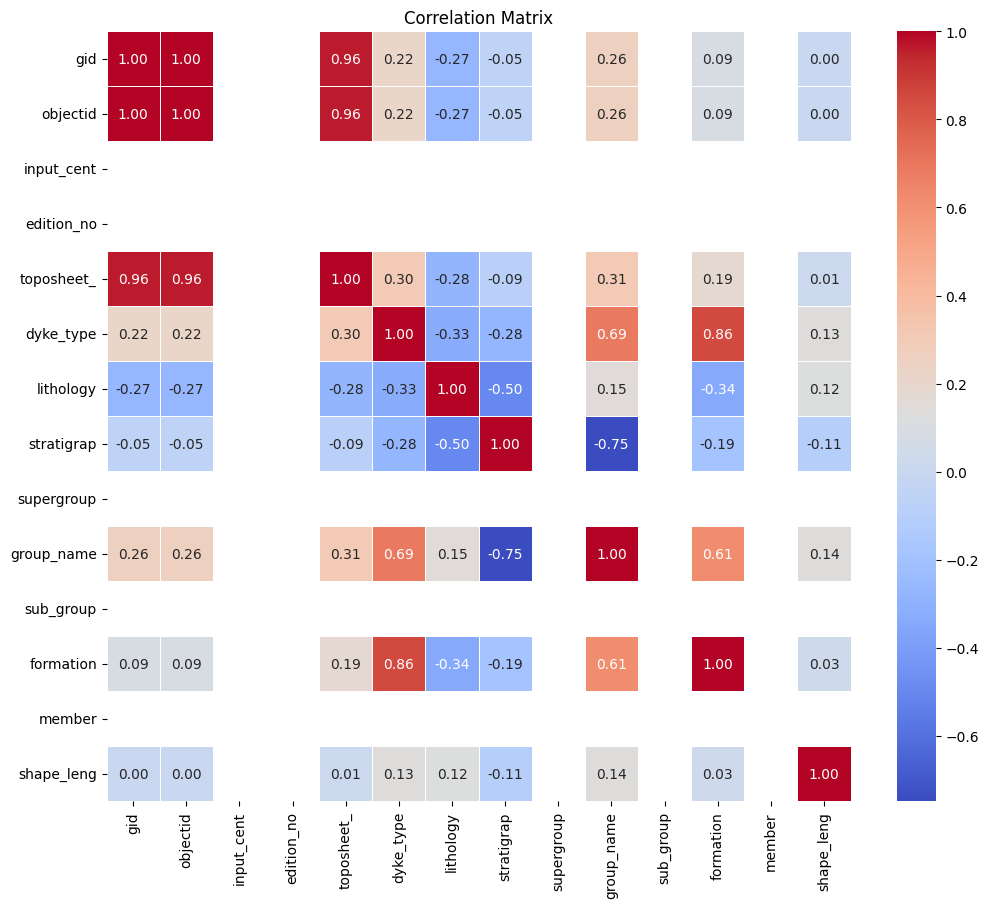

Random Forest Accuracy: 1.71%
XGBoost Accuracy: 1.60%
Gradient Boosting Accuracy: 1.49%

🔹 Best Model: Random Forest with Accuracy: 1.71%


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# Load the dyke shapefile
shapefile_path = "/content/dyke_line_25k_ngdr.shp"
gdf = gpd.read_file(shapefile_path)

# Drop geometry column
if "geometry" in gdf.columns:
    gdf = gdf.drop(columns=["geometry"])

# Fill missing values
for col in gdf.columns:
    if gdf[col].dtype == "object":
        gdf[col] = gdf[col].fillna("Unknown")
    else:
        gdf[col] = gdf[col].fillna(gdf[col].median())

# Drop irrelevant columns if present
gdf = gdf.drop(columns=["accession_", "remarks"], errors="ignore")

# Encode categorical variables
for col in gdf.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    gdf[col] = le.fit_transform(gdf[col])

# Save cleaned dataset
cleaned_csv_path = "dyke_cleaned_dataset.csv"
gdf.to_csv(cleaned_csv_path, index=False)
print(f"Cleaned dataset saved as {cleaned_csv_path}")

# Correlation matrix
correlation_matrix = gdf.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

# Filter features with correlation > 0.1 with target
target_column = "shape_leng"
cor_target = correlation_matrix[target_column].abs()
relevant_features = cor_target[cor_target > 0.1].index.tolist()
if target_column not in relevant_features:
    relevant_features.append(target_column)
gdf = gdf[relevant_features]

# Standardize numerical columns (except target)
scaler = StandardScaler()
numerical_cols = gdf.select_dtypes(include=[np.number]).columns.drop(target_column)
gdf[numerical_cols] = scaler.fit_transform(gdf[numerical_cols])

# Define features and target
X = gdf.drop(columns=[target_column])
y = gdf[target_column]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
rf = RandomForestRegressor(n_estimators=100, random_state=42)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, objective="reg:squarederror", random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

# Train models
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
gb.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)
y_pred_gb = gb.predict(X_test)

# Evaluate
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

mean_y = np.mean(y_test)
accuracy_rf = 100 * (1 - (rmse_rf / mean_y))
accuracy_xgb = 100 * (1 - (rmse_xgb / mean_y))
accuracy_gb = 100 * (1 - (rmse_gb / mean_y))

# Print results
print(f"Random Forest Accuracy: {accuracy_rf:.2f}%")
print(f"XGBoost Accuracy: {accuracy_xgb:.2f}%")
print(f"Gradient Boosting Accuracy: {accuracy_gb:.2f}%")

# Best model
best_model = max([(accuracy_rf, "Random Forest"), (accuracy_xgb, "XGBoost"), (accuracy_gb, "Gradient Boosting")])
print(f"\n🔹 Best Model: {best_model[1]} with Accuracy: {best_model[0]:.2f}%")


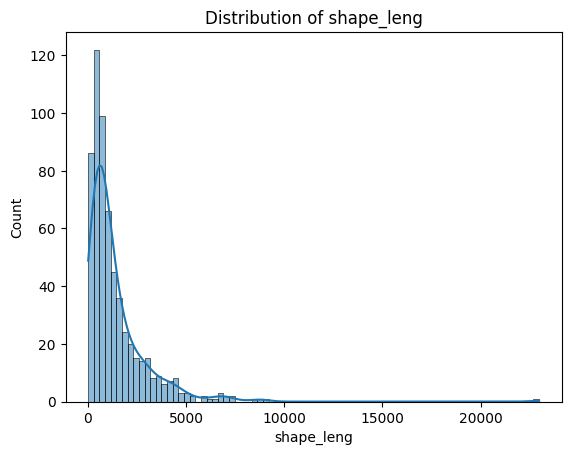

<ipython-input-14-c200723464ab>:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdf["shape_leng"] = np.log1p(gdf["shape_leng"])


Random Forest Accuracy: 17.64%
XGBoost Accuracy: 17.15%
Gradient Boosting Accuracy: 12.44%

🔹 Best Model: Random Forest with Accuracy: 17.64%


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
shapefile_path = "/content/dyke_line_25k_ngdr.shp"
gdf = gpd.read_file(shapefile_path)

# --- Drop geometry column
if "geometry" in gdf.columns:
    gdf = gdf.drop(columns=["geometry"])

# --- Fill missing values
for col in gdf.columns:
    if gdf[col].dtype == "object":
        gdf[col] = gdf[col].fillna("Unknown")
    else:
        gdf[col] = gdf[col].fillna(gdf[col].median())

# --- Drop irrelevant columns
gdf = gdf.drop(columns=["accession_", "remarks"], errors="ignore")

# --- Encode categorical
for col in gdf.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    gdf[col] = le.fit_transform(gdf[col])

# --- OPTIONAL: Visualize & remove outliers from shape_leng
plt.figure()
sns.histplot(gdf["shape_leng"], kde=True)
plt.title("Distribution of shape_leng")
plt.show()

# Remove extreme outliers (keep 1st–99th percentile)
q_low = gdf["shape_leng"].quantile(0.01)
q_high = gdf["shape_leng"].quantile(0.99)
gdf = gdf[(gdf["shape_leng"] >= q_low) & (gdf["shape_leng"] <= q_high)]

# --- Log-transform target if highly skewed
gdf["shape_leng"] = np.log1p(gdf["shape_leng"])

# --- Correlation filter
correlation_matrix = gdf.corr()
target_column = "shape_leng"
cor_target = correlation_matrix[target_column].abs()
relevant_features = cor_target[cor_target > 0.1].index.tolist()
if target_column not in relevant_features:
    relevant_features.append(target_column)
gdf = gdf[relevant_features]

# --- Split features and target
X = gdf.drop(columns=[target_column])
y = gdf[target_column]

# --- Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Standardization (fit only on training set)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- Define models
rf = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42)
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=8, objective="reg:squarederror", random_state=42)
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=8, random_state=42)

# --- Train models
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
gb.fit(X_train, y_train)

# --- Predictions
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)
y_pred_gb = gb.predict(X_test)

# --- Reverse log transformation (expm1) for final accuracy
y_test_exp = np.expm1(y_test)
y_pred_rf_exp = np.expm1(y_pred_rf)
y_pred_xgb_exp = np.expm1(y_pred_xgb)
y_pred_gb_exp = np.expm1(y_pred_gb)

# --- Evaluate
rmse_rf = np.sqrt(mean_squared_error(y_test_exp, y_pred_rf_exp))
rmse_xgb = np.sqrt(mean_squared_error(y_test_exp, y_pred_xgb_exp))
rmse_gb = np.sqrt(mean_squared_error(y_test_exp, y_pred_gb_exp))

mean_y = np.mean(y_test_exp)
accuracy_rf = 100 * (1 - (rmse_rf / mean_y))
accuracy_xgb = 100 * (1 - (rmse_xgb / mean_y))
accuracy_gb = 100 * (1 - (rmse_gb / mean_y))

# --- Results
print(f"Random Forest Accuracy: {accuracy_rf:.2f}%")
print(f"XGBoost Accuracy: {accuracy_xgb:.2f}%")
print(f"Gradient Boosting Accuracy: {accuracy_gb:.2f}%")

best_model = max([(accuracy_rf, "Random Forest"), (accuracy_xgb, "XGBoost"), (accuracy_gb, "Gradient Boosting")])
print(f"\n🔹 Best Model: {best_model[1]} with Accuracy: {best_model[0]:.2f}%")


✅ Cleaned dataset saved as dyke_cleaned_dataset.csv


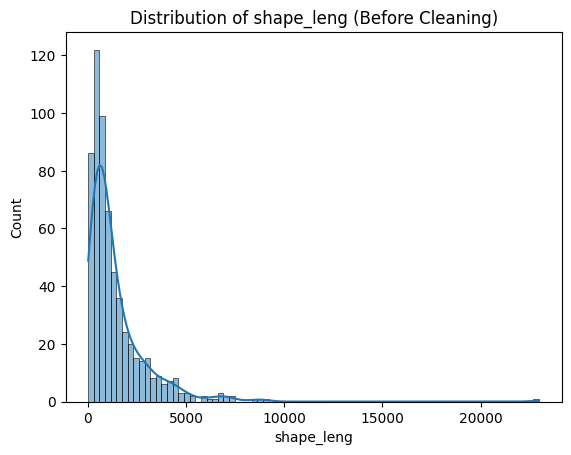

<ipython-input-15-792bd70ed0db>:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdf["shape_leng"] = np.log1p(gdf["shape_leng"])


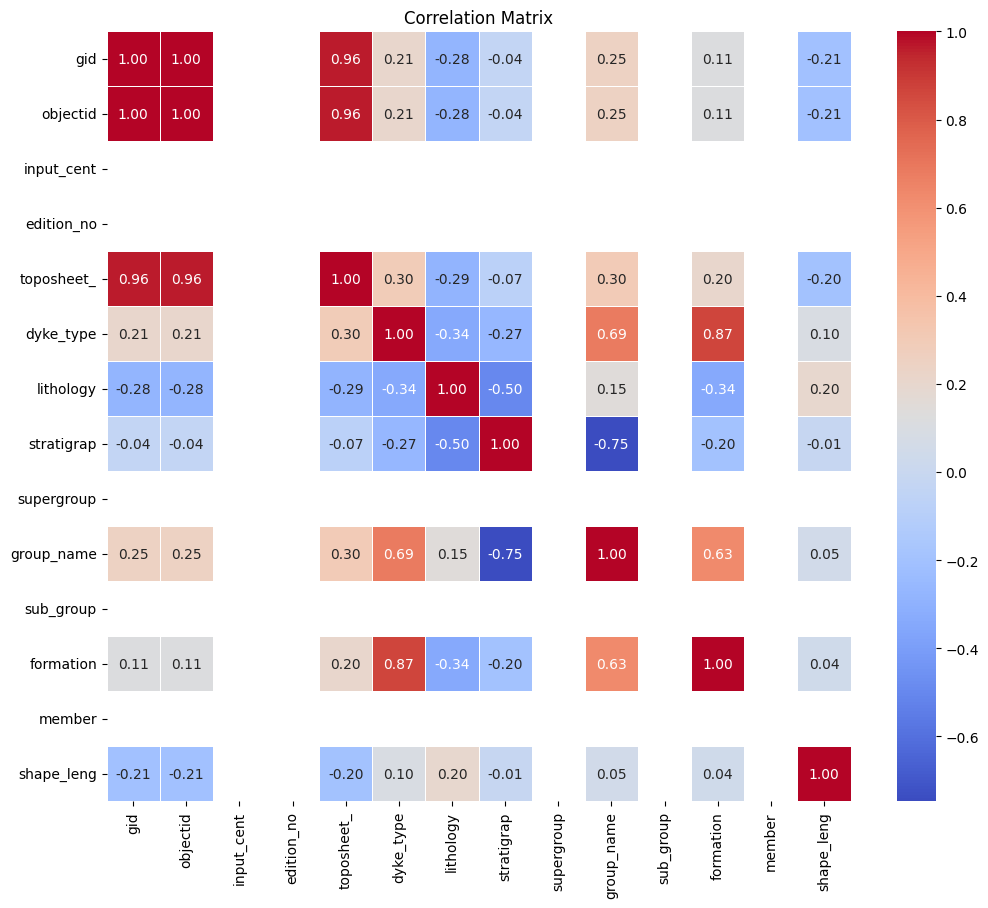


📊 Model Accuracies:
  • Random Forest Accuracy:       17.64%
  • XGBoost Accuracy:             17.15%
  • Gradient Boosting Accuracy:   12.44%

✅ Best Model: Random Forest with Accuracy: 17.64%


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# --- Load the dyke shapefile
shapefile_path = "/content/dyke_line_25k_ngdr.shp"  # Update path if needed
gdf = gpd.read_file(shapefile_path)

# --- Drop geometry column
if "geometry" in gdf.columns:
    gdf = gdf.drop(columns=["geometry"])

# --- Fill missing values
for col in gdf.columns:
    if gdf[col].dtype == "object":
        gdf[col] = gdf[col].fillna("Unknown")
    else:
        gdf[col] = gdf[col].fillna(gdf[col].median())

# --- Drop irrelevant columns
gdf = gdf.drop(columns=["accession_", "remarks"], errors="ignore")

# --- Encode categorical variables
for col in gdf.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    gdf[col] = le.fit_transform(gdf[col])

# --- Save cleaned dataset
cleaned_csv_path = "dyke_cleaned_dataset.csv"
gdf.to_csv(cleaned_csv_path, index=False)
print(f"✅ Cleaned dataset saved as {cleaned_csv_path}")

# --- Plot target distribution
plt.figure()
sns.histplot(gdf["shape_leng"], kde=True)
plt.title("Distribution of shape_leng (Before Cleaning)")
plt.show()

# --- Remove outliers in target (1st to 99th percentile)
q_low = gdf["shape_leng"].quantile(0.01)
q_high = gdf["shape_leng"].quantile(0.99)
gdf = gdf[(gdf["shape_leng"] >= q_low) & (gdf["shape_leng"] <= q_high)]

# --- Log-transform the target
gdf["shape_leng"] = np.log1p(gdf["shape_leng"])

# --- Correlation matrix
correlation_matrix = gdf.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

# --- Feature selection by correlation
target_column = "shape_leng"
cor_target = correlation_matrix[target_column].abs()
relevant_features = cor_target[cor_target > 0.1].index.tolist()
if target_column not in relevant_features:
    relevant_features.append(target_column)
gdf = gdf[relevant_features]

# --- Define X and y
X = gdf.drop(columns=[target_column])
y = gdf[target_column]

# --- Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- Define models
rf = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42)
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=8, objective="reg:squarederror", random_state=42)
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=8, random_state=42)

# --- Train models
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
gb.fit(X_train, y_train)

# --- Predict
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)
y_pred_gb = gb.predict(X_test)

# --- Reverse log transformation for accuracy calculation
y_test_exp = np.expm1(y_test)
y_pred_rf_exp = np.expm1(y_pred_rf)
y_pred_xgb_exp = np.expm1(y_pred_xgb)
y_pred_gb_exp = np.expm1(y_pred_gb)

# --- Evaluate models
rmse_rf = np.sqrt(mean_squared_error(y_test_exp, y_pred_rf_exp))
rmse_xgb = np.sqrt(mean_squared_error(y_test_exp, y_pred_xgb_exp))
rmse_gb = np.sqrt(mean_squared_error(y_test_exp, y_pred_gb_exp))

mean_y = np.mean(y_test_exp)
accuracy_rf = 100 * (1 - (rmse_rf / mean_y))
accuracy_xgb = 100 * (1 - (rmse_xgb / mean_y))
accuracy_gb = 100 * (1 - (rmse_gb / mean_y))

# --- Print Results
print(f"\n📊 Model Accuracies:")
print(f"  • Random Forest Accuracy:       {accuracy_rf:.2f}%")
print(f"  • XGBoost Accuracy:             {accuracy_xgb:.2f}%")
print(f"  • Gradient Boosting Accuracy:   {accuracy_gb:.2f}%")

best_model = max([(accuracy_rf, "Random Forest"), (accuracy_xgb, "XGBoost"), (accuracy_gb, "Gradient Boosting")])
print(f"\n✅ Best Model: {best_model[1]} with Accuracy: {best_model[0]:.2f}%")


✅ Cleaned dataset saved as dyke_cleaned_dataset.csv


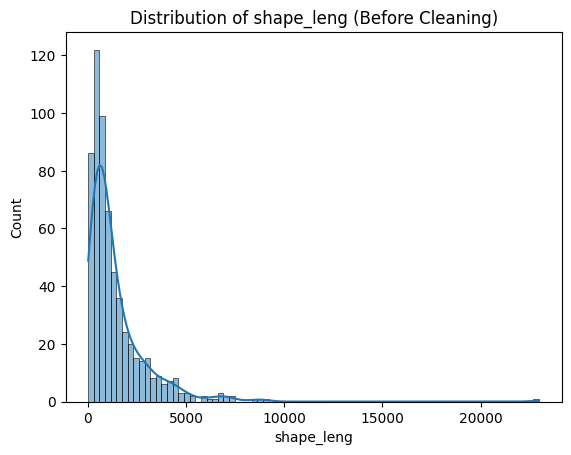

<ipython-input-16-e53cf4338ceb>:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdf["shape_leng"] = np.log1p(gdf["shape_leng"])


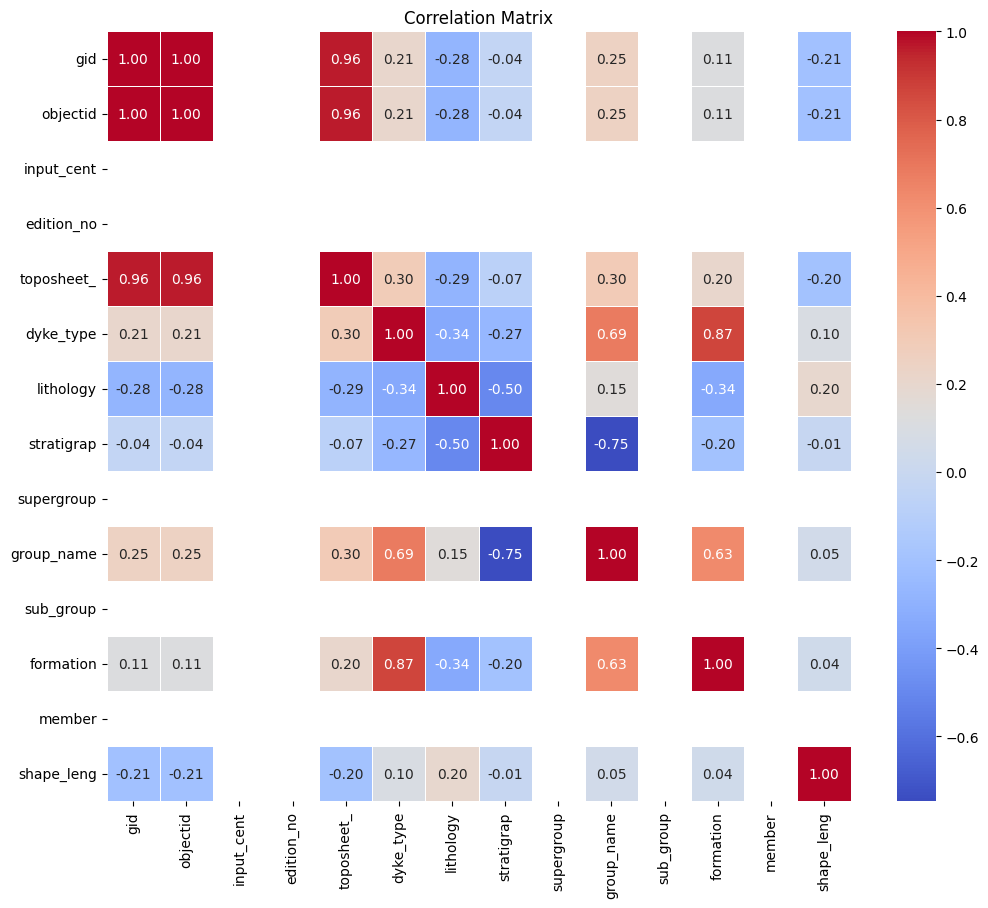


📊 Model Accuracies:
  • Random Forest Accuracy:       17.64%
  • XGBoost Accuracy:             17.15%
  • Gradient Boosting Accuracy:   12.44%

✅ Best Model: Random Forest with Accuracy: 17.64%


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# --- Load the dyke shapefile
shapefile_path = "/content/dyke_line_25k_ngdr.dbf"  # Update path if needed
gdf = gpd.read_file(shapefile_path)

# --- Drop geometry column
if "geometry" in gdf.columns:
    gdf = gdf.drop(columns=["geometry"])

# --- Fill missing values
for col in gdf.columns:
    if gdf[col].dtype == "object":
        gdf[col] = gdf[col].fillna("Unknown")
    else:
        gdf[col] = gdf[col].fillna(gdf[col].median())

# --- Drop irrelevant columns
gdf = gdf.drop(columns=["accession_", "remarks"], errors="ignore")

# --- Encode categorical variables
for col in gdf.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    gdf[col] = le.fit_transform(gdf[col])

# --- Save cleaned dataset
cleaned_csv_path = "dyke_cleaned_dataset.csv"
gdf.to_csv(cleaned_csv_path, index=False)
print(f"✅ Cleaned dataset saved as {cleaned_csv_path}")

# --- Plot target distribution
plt.figure()
sns.histplot(gdf["shape_leng"], kde=True)
plt.title("Distribution of shape_leng (Before Cleaning)")
plt.show()

# --- Remove outliers in target (1st to 99th percentile)
q_low = gdf["shape_leng"].quantile(0.01)
q_high = gdf["shape_leng"].quantile(0.99)
gdf = gdf[(gdf["shape_leng"] >= q_low) & (gdf["shape_leng"] <= q_high)]

# --- Log-transform the target
gdf["shape_leng"] = np.log1p(gdf["shape_leng"])

# --- Correlation matrix
correlation_matrix = gdf.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

# --- Feature selection by correlation
target_column = "shape_leng"
cor_target = correlation_matrix[target_column].abs()
relevant_features = cor_target[cor_target > 0.1].index.tolist()
if target_column not in relevant_features:
    relevant_features.append(target_column)
gdf = gdf[relevant_features]

# --- Define X and y
X = gdf.drop(columns=[target_column])
y = gdf[target_column]

# --- Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- Define models
rf = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42)
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=8, objective="reg:squarederror", random_state=42)
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=8, random_state=42)

# --- Train models
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
gb.fit(X_train, y_train)

# --- Predict
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)
y_pred_gb = gb.predict(X_test)

# --- Reverse log transformation for accuracy calculation
y_test_exp = np.expm1(y_test)
y_pred_rf_exp = np.expm1(y_pred_rf)
y_pred_xgb_exp = np.expm1(y_pred_xgb)
y_pred_gb_exp = np.expm1(y_pred_gb)

# --- Evaluate models
rmse_rf = np.sqrt(mean_squared_error(y_test_exp, y_pred_rf_exp))
rmse_xgb = np.sqrt(mean_squared_error(y_test_exp, y_pred_xgb_exp))
rmse_gb = np.sqrt(mean_squared_error(y_test_exp, y_pred_gb_exp))

mean_y = np.mean(y_test_exp)
accuracy_rf = 100 * (1 - (rmse_rf / mean_y))
accuracy_xgb = 100 * (1 - (rmse_xgb / mean_y))
accuracy_gb = 100 * (1 - (rmse_gb / mean_y))

# --- Print Results
print(f"\n📊 Model Accuracies:")
print(f"  • Random Forest Accuracy:       {accuracy_rf:.2f}%")
print(f"  • XGBoost Accuracy:             {accuracy_xgb:.2f}%")
print(f"  • Gradient Boosting Accuracy:   {accuracy_gb:.2f}%")

best_model = max([(accuracy_rf, "Random Forest"), (accuracy_xgb, "XGBoost"), (accuracy_gb, "Gradient Boosting")])
print(f"\n✅ Best Model: {best_model[1]} with Accuracy: {best_model[0]:.2f}%")
